**1. Understanding Gradient Descent and Momentum [3 Marks]**

Generate the following two functions:

Dataset 1:

In [ ]:
import numpy as np

num_samples = 40
np.random.seed(45)

# Generate data
x1 = np.random.uniform(-20, 20, num_samples)
f_x = 100*x1 + 1
eps = np.random.randn(num_samples)
y = f_x + eps

Dataset 2:

In [ ]:
np.random.seed(45)
num_samples = 40

# Generate data
x1 = np.random.uniform(-1, 1, num_samples)
f_x = 3*x1 + 4
eps = np.random.randn(num_samples)
y = f_x + eps

### [2 marks] Implement full-batch gradient descent and stochastic gradient descent

Implement **full-batch gradient descent (GD)** and **stochastic gradient descent (SGD)** for linear regression using the given datasets.

**Convergence criterion:** reach an $\epsilon$-neighborhood of the minimizer with $\epsilon = 0.001$.  
Your estimate $\boldsymbol{\theta}_t$ is considered **converged** once it is within distance $\epsilon$ of the true minimizer $\boldsymbol{\theta}$:


**Tasks (for each method and dataset):**
- Determine the **average number of steps** required to satisfy the convergence criterion.
- **Visualize** the convergence process over **15 epochs**.

**Provide visualizations:**
- **Contour plots** of the optimization process at different epochs *(or an animation/GIF)*.
- A **loss vs epochs** plot for each method and dataset.



# **Cell 1 — Setup & installs**

**1) Libraries & environment**


*   Install imageio (GIFs), import NumPy, PyTorch, Matplotlib, and Path for file I/O.

*   Set plt.rcParams["figure.dpi"] = 140 for crisp figures in Colab.


* Device: DEVICE = "cpu" (datasets are small).



**2) Convergence & safety**

* ε-neighborhood: EPS = 1e-3 → stop when
∥ 𝜃𝑡 − 𝜃∗∥ 2< 𝜀


* Iteration cap: MAX_STEPS = 50_000 to prevent infinite runs.

**3) Visualization**

EPOCHS_FOR_PLOTS = 15 → only visualize the first 15 epochs (clean, comparable panels).

**4) Statistics**

N_RUNS = 20 random restarts → report mean ± std steps-to-ε (robust comparison).

**5) Optimization settings**

Learning rates:

* LR_BATCH → full-batch gradient descent.

* LR_SGD → stochastic gradient descent (bs=1).

**6) Outputs & reproducibility**

Create gd_sgd_results/ to save PNGs/GIFs.



In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import gridspec, cm
from pathlib import Path
import imageio.v2 as imageio

plt.rcParams["figure.dpi"] = 140

DEVICE = "cpu"
EPS = 1e-3                   # convergence epsilon: ‖θ_t - θ*‖ < EPS
MAX_STEPS = 50_000           # safety cap
EPOCHS_FOR_PLOTS = 15        # visualize first 15 epochs
N_RUNS = 20                  # average steps across random inits/shuffles
LR_BATCH = 1e-2              # learning rate for full-batch GD
LR_SGD = 1e-2                # learning rate for SGD

RESULTS_DIR = Path("gd_sgd_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PyTorch:', torch.__version__)


PyTorch: 2.8.0+cu126


# **Cell 2- Dataset generation**



1) **Build two synthetic linear-regression datasets (fixed seeds).**
   - **Dataset 1:** $x \sim U[-20, 20]$, true model $y = 100x + 1 + \epsilon$.
   - **Dataset 2:** $x \sim U[-1, 1]$, true model $y = 3x + 4 + \epsilon$.
   - **Noise:** $\epsilon \sim N(0, 1)$.
   - `np.random.seed(45)` ensures reproducibility.



2) **Form the design matrix with an intercept.**
   - $X = [1, x]$ so the parameter vector is $\theta = [b, w]$.
   - Convert $x$ and $y$ to `torch.float32` tensors on `DEVICE`.



3) **Quick sanity check.**
   - Creates $X1,y1$ and $X2, y2$ then prints their shapes to confirm dimensions ($40 \times 2$ and $40$).

In [ ]:
def make_dataset_1():
    num_samples = 40
    np.random.seed(45)
    x1 = np.random.uniform(-20, 20, num_samples)
    f_x = 100*x1 + 1
    eps = np.random.randn(num_samples)
    y = f_x + eps
    X = np.stack([np.ones_like(x1), x1], axis=1)    # [1, x]
    return (torch.tensor(X, dtype=torch.float32, device=DEVICE),
            torch.tensor(y, dtype=torch.float32, device=DEVICE))

def make_dataset_2():
    np.random.seed(45)
    num_samples = 40
    x1 = np.random.uniform(-1, 1, num_samples)
    f_x = 3*x1 + 4
    eps = np.random.randn(num_samples)
    y = f_x + eps
    X = np.stack([np.ones_like(x1), x1], axis=1)
    return (torch.tensor(X, dtype=torch.float32, device=DEVICE),
            torch.tensor(y, dtype=torch.float32, device=DEVICE))

X1, y1 = make_dataset_1()
X2, y2 = make_dataset_2()
print('Dataset1 shapes:', X1.shape, y1.shape, '| Dataset2 shapes:', X2.shape, y2.shape)


Dataset1 shapes: torch.Size([40, 2]) torch.Size([40]) | Dataset2 shapes: torch.Size([40, 2]) torch.Size([40])


## **Cell 3 - Closed-form minimizer & loss**

## **True Minimizer $\theta^*$ (Normal Equation)**

**Formula:**

$$ \theta^* = (X^{T}X)^{-1}X^{T}y $$

Implemented using `torch.linalg.solve(H, g)` where:
* $H = X^{T}X$
* $g = X^{T}y$

This method **avoids explicit matrix inversion**, making it more stable and efficient.

**Output:** $\theta^* = [b^*,\, w^*]$ (intercept and slope).


# **Mean Squared Error (MSE) Loss**

**Prediction:**

$$ \hat{y} = X\theta $$

**Loss function:**

$$ J(\theta) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2 $$

Implemented using `F.mse_loss(yhat, y, reduction="mean")`.

In [ ]:
def true_minimizer(X, y):
    # θ* = (X^T X)^{-1} X^T y  (using a stable solver)
    XT = X.t()
    H = XT @ X
    g = XT @ y
    return torch.linalg.solve(H, g)    # [b*, w*]

def mse_loss_theta(theta, X, y):
    # θ = [b, w]
    yhat = X @ theta
    return F.mse_loss(yhat, y, reduction="mean")


# **Cell 4 - Optimizers: Full-batch GD & SGD**

### 1) `full_batch_gd(...)` — Full-batch Gradient Descent

- **Update** uses the **entire dataset** each step:
  $$ \theta \leftarrow \theta - \eta \nabla J(\theta), \quad \nabla J(\theta) = \frac{2}{n} X^T (X\theta - y) $$
- **Logging:** Records parameter path, per-epoch loss, and snapshots for the first `log_epochs` (default 15) to plot contours/trajectories.
- **Convergence:** Stops when $\|\theta - \theta^*\|_2 < \epsilon$ or `MAX_STEPS` is hit.
- **Returns:** `(theta_path, epoch_losses, steps, epoch_snaps)`.



### 2) `sgd(...)` — Stochastic Gradient Descent (batch size = 1)

- **One sample update** per step (indices **shuffled each epoch**):
  $$ \theta \leftarrow \theta - \eta \nabla_{\text{1-sample}} J(\theta) $$
  with per-sample gradient $2(\langle x_i, \theta \rangle - y_i)x_i$.
- **Logging:** Per-epoch full-batch MSE at epoch boundaries; parameter path at step resolution.
- **Randomness:** `seed` controls shuffling; used to average steps across runs.
- **Convergence:** Same $\epsilon$-neighborhood test; continues past the visual horizon to measure steps-to-$\epsilon$.
- **Returns:** `(theta_path, epoch_losses, steps, epoch_snaps)`.


In [ ]:
def full_batch_gd(X, y, theta_star, lr=LR_BATCH, max_steps=MAX_STEPS,
                  log_epochs=EPOCHS_FOR_PLOTS, eps=EPS):
    theta = torch.randn(2, device=DEVICE)
    theta_path = [theta.clone().detach()]
    epoch_losses, epoch_snaps = [], [theta.clone().detach()]
    steps = 0

    for epoch in range(log_epochs):
        theta = theta.clone().detach().requires_grad_(True)
        loss = mse_loss_theta(theta, X, y)
        loss.backward()
        with torch.no_grad():
            theta -= lr * theta.grad
        theta = theta.detach()
        steps += 1

        theta_path.append(theta.clone())
        epoch_losses.append(loss.item())
        epoch_snaps.append(theta.clone())

        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            while len(epoch_losses) < log_epochs:
                epoch_losses.append(epoch_losses[-1])
                epoch_snaps.append(theta.clone())
            return theta_path, epoch_losses, steps, epoch_snaps

    while steps < max_steps:
        theta = theta.clone().detach().requires_grad_(True)
        loss = mse_loss_theta(theta, X, y)
        loss.backward()
        with torch.no_grad():
            theta -= lr * theta.grad
        theta = theta.detach()
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            break

    return theta_path, epoch_losses, steps, epoch_snaps

def sgd(X, y, theta_star, lr=LR_SGD, max_steps=MAX_STEPS,
        log_epochs=EPOCHS_FOR_PLOTS, seed=123, eps=EPS):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    theta = torch.randn(2, device=DEVICE)
    theta_path = [theta.clone().detach()]
    epoch_losses, epoch_snaps = [], [theta.clone().detach()]
    steps = 0

    for epoch in range(log_epochs):
        idxs = rng.permutation(n)
        for i in idxs:
            xi = X[i]; yi = y[i]
            theta = theta.clone().detach().requires_grad_(True)
            loss_i = (torch.dot(xi, theta) - yi) ** 2
            loss_i.backward()
            with torch.no_grad():
                theta -= lr * theta.grad
            theta = theta.detach()
            steps += 1

            theta_path.append(theta.clone())
            if torch.linalg.vector_norm(theta - theta_star).item() < eps:
                while len(epoch_losses) < log_epochs:
                    epoch_losses.append(mse_loss_theta(theta, X, y).item())
                    epoch_snaps.append(theta.clone())
                return theta_path, epoch_losses, steps, epoch_snaps


        epoch_losses.append(mse_loss_theta(theta, X, y).item())
        epoch_snaps.append(theta.clone())


    rng2 = np.random.default_rng(seed + 999)
    while steps < max_steps:
        i = int(rng2.integers(0, n))
        xi = X[i]; yi = y[i]
        theta = theta.clone().detach().requires_grad_(True)
        loss_i = (torch.dot(xi, theta) - yi) ** 2
        loss_i.backward()
        with torch.no_grad():
            theta -= lr * theta.grad
        theta = theta.detach()
        steps += 1
        if torch.linalg.vector_norm(theta - theta_star).item() < eps:
            break

    return theta_path, epoch_losses, steps, epoch_snaps


## **Cell 5 - Visualization Functions**

I. `make_contour(ax, X, y, theta_path_epochs, title="")`
- Plots **MSE loss contours** over parameter space ($b, w$) and overlays the **parameter trajectory**.
- Auto-sets the plot span based on the scale of $x$ (wide vs narrow range).
- **Steps:**
  1. Compute $\theta^*$ (closed-form minimizer) for reference (black ★).
  2. Build a grid over $b, w$; evaluate MSE on the grid to draw contour lines.
  3. Plot the path `theta_path_epochs` as red markers/lines.
- **Inputs:** Matplotlib axis `ax`, design matrix `X`, targets `y`, list of epoch snapshots `theta_path_epochs`.
- **Output:** A labeled contour plot with the trajectory and $\theta^*$.




II. `plot_losses(ax, losses, title="")`
- Simple **loss vs. epoch** line plot (MSE per epoch).
- X-axis = epoch index (starting at 1), Y-axis = MSE.
- Adds a grid and title for readability.



III.`save_gif(theta_path_steps, X, y, outpath, every=5)`
- Creates an **animation (GIF)** of the optimization path in ($b, w$)-space.
- **Workflow:**
  1. Pre-draw contours via `make_contour(...)` using the **first** and **last** parameters to set the view.
  2. Iterate through `theta_path_steps` (every `every` steps), dropping a red dot for the current $\theta$.
  3. Capture each frame and save to `outpath` via `imageio.mimsave`.

In [ ]:

def make_contour(ax, X, y, theta_path_epochs, title=""):
    theta_star = true_minimizer(X, y)
    b_star, w_star = theta_star.tolist()

    # span depends on x-range scale
    b_span = 6.0 if X[:,1].abs().max().item() <= 1.5 else 50.0
    w_span = 6.0 if X[:,1].abs().max().item() <= 1.5 else 150.0

    b_vals = np.linspace(b_star - b_span, b_star + b_span, 200)
    w_vals = np.linspace(w_star - w_span, w_star + w_span, 200)
    B, W = np.meshgrid(b_vals, w_vals)
    loss_grid = np.zeros_like(B)

    with torch.no_grad():
        for i in range(B.shape[0]):
            BW_row = torch.tensor(np.stack([B[i], W[i]], axis=-1),
                                  dtype=torch.float32, device=DEVICE)
            yhat = X @ BW_row.T
            diffs = yhat - y.unsqueeze(1)
            loss_grid[i] = (diffs.pow(2).mean(dim=0)).cpu().numpy()

    CS = ax.contour(B, W, loss_grid, levels=20, cmap=cm.viridis)
    ax.clabel(CS, inline=True, fontsize=6, fmt="%.1f")

    bs = [t[0].item() for t in theta_path_epochs]
    ws = [t[1].item() for t in theta_path_epochs]
    ax.plot(bs, ws, marker="o", lw=1.5, c="tab:red", label="trajectory")
    ax.scatter([b_star], [w_star], c="black", s=30, marker="*", label="θ*")
    ax.set_xlabel("b (intercept)")
    ax.set_ylabel("w (slope)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=7)

def plot_losses(ax, losses, title=""):
    ax.plot(range(1, len(losses)+1), losses, marker="o")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(title)
    ax.grid(True, ls="--", alpha=0.4)

def save_gif(theta_path_steps, X, y, outpath, every=5):
    """Animated optimization path on the contour map."""
    frames = []
    fig, ax = plt.subplots(figsize=(4.5, 3.8))

    make_contour(ax, X, y, [theta_path_steps[0], theta_path_steps[-1]],
                 title="Optimization path (animated)")
    for t in range(0, len(theta_path_steps), every):
        th = theta_path_steps[t]
        ax.plot([th[0].item()], [th[1].item()], 'o', c="tab:red")
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        img = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(img.copy())
    imageio.mimsave(outpath, frames, fps=12)
    plt.close(fig)


## **Cell 6 - Experiment Runner**

**Function:** `run_experiment(X, y, dataset_name="Dataset")`


#### What it does
- Computes the **closed-form minimizer** $\theta^*$ for reference.
- Runs **one representative** training for each method (using fixed seeds) to produce plots:
  - **Full-batch GD** → parameter snapshots & loss for the first `EPOCHS_FOR_PLOTS`.
  - **SGD (bs=1)** → parameter snapshots & loss for the first `EPOCHS_FOR_PLOTS`.



#### Averaging (steps-to-$\epsilon$)
- Repeats each method `N_RUNS` times (with different initializations/shuffles).
- Prints the mean $\pm$ std, min/max **steps to convergence**, where convergence is defined as $\|\theta - \theta^*\|_2 < \epsilon$.



#### Visualizations
- Creates a **$2 \times 2$ panel** containing:
  - Contour + trajectory (Full-batch GD)
  - Contour + trajectory (SGD)
  - Loss vs epochs (Full-batch)
  - Loss vs epochs (SGD)
- Saves the resulting PNG to: `gd_sgd_results/{dataset_name}_contours_and_losses.png`.

In [ ]:
def run_experiment(X, y, dataset_name="Dataset"):
    theta_star = true_minimizer(X, y)


    path_b, losses_b, steps_b, snaps_b = full_batch_gd(
        X, y, theta_star, lr=LR_BATCH, log_epochs=EPOCHS_FOR_PLOTS, eps=EPS
    )
    path_s, losses_s, steps_s, snaps_s = sgd(
        X, y, theta_star, lr=LR_SGD, log_epochs=EPOCHS_FOR_PLOTS, seed=2025, eps=EPS
    )


    steps_batch, steps_sgd = [], []
    for r in range(N_RUNS):
        _, _, sb, _ = full_batch_gd(X, y, theta_star, lr=LR_BATCH, log_epochs=1, eps=EPS)
        steps_batch.append(sb)
        _, _, ss, _ = sgd(X, y, theta_star, lr=LR_SGD, log_epochs=1, seed=1000+r, eps=EPS)
        steps_sgd.append(ss)

    print(f"\n=== {dataset_name} ===")
    print(f"θ* (closed form): b*={theta_star[0].item():.6f}, w*={theta_star[1].item():.6f}")
    print(f"Average steps to ε={EPS} | Full-batch GD: "
          f"{np.mean(steps_batch):.1f} ± {np.std(steps_batch):.1f} "
          f"(min={np.min(steps_batch)}, max={np.max(steps_batch)})")
    print(f"Average steps to ε={EPS} | SGD (bs=1):  "
          f"{np.mean(steps_sgd):.1f} ± {np.std(steps_sgd):.1f} "
          f"(min={np.min(steps_sgd)}, max={np.max(steps_sgd)})")

    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.0, 1.0])

    ax1 = fig.add_subplot(gs[0, 0])
    make_contour(ax1, X, y, snaps_b, title=f"{dataset_name} | Full-batch GD (0..{EPOCHS_FOR_PLOTS})")

    ax2 = fig.add_subplot(gs[0, 1])
    make_contour(ax2, X, y, snaps_s, title=f"{dataset_name} | SGD (0..{EPOCHS_FOR_PLOTS})")

    ax3 = fig.add_subplot(gs[1, 0])
    plot_losses(ax3, losses_b, title=f"{dataset_name} | Loss vs Epochs (Full-batch)")

    ax4 = fig.add_subplot(gs[1, 1])
    plot_losses(ax4, losses_s, title=f"{dataset_name} | Loss vs Epochs (SGD)")

    fig.suptitle(f"Optimization on {dataset_name}", fontsize=12)
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    out_png = RESULTS_DIR / f"{dataset_name}_contours_and_losses.png"
    fig.savefig(out_png)
    plt.show()

    try:
        save_gif(path_b, X, y, RESULTS_DIR / f"{dataset_name}_fullbatch.gif", every=1)
        save_gif(path_s, X, y, RESULTS_DIR / f"{dataset_name}_sgd.gif",
                 every=max(1, len(path_s)//150))
        print(f"Saved figures/GIFs to: {RESULTS_DIR}")
    except Exception as e:
        print("GIF generation skipped (install 'imageio' if needed).", e)

    return {
        "theta_star": theta_star.detach().cpu().numpy(),
        "gd_steps": np.array(steps_batch),
        "sgd_steps": np.array(steps_sgd),
        "eps": EPS
    }


# **Full Batch Gradient Descent and Stochastic Gradient Descent for Dataset 1**


=== Dataset1 ===
θ* (closed form): b*=0.950667, w*=99.984116
Average steps to ε=0.001 | Full-batch GD: 50000.0 ± 0.0 (min=50000, max=50000)
Average steps to ε=0.001 | SGD (bs=1):  50000.0 ± 0.0 (min=50000, max=50000)


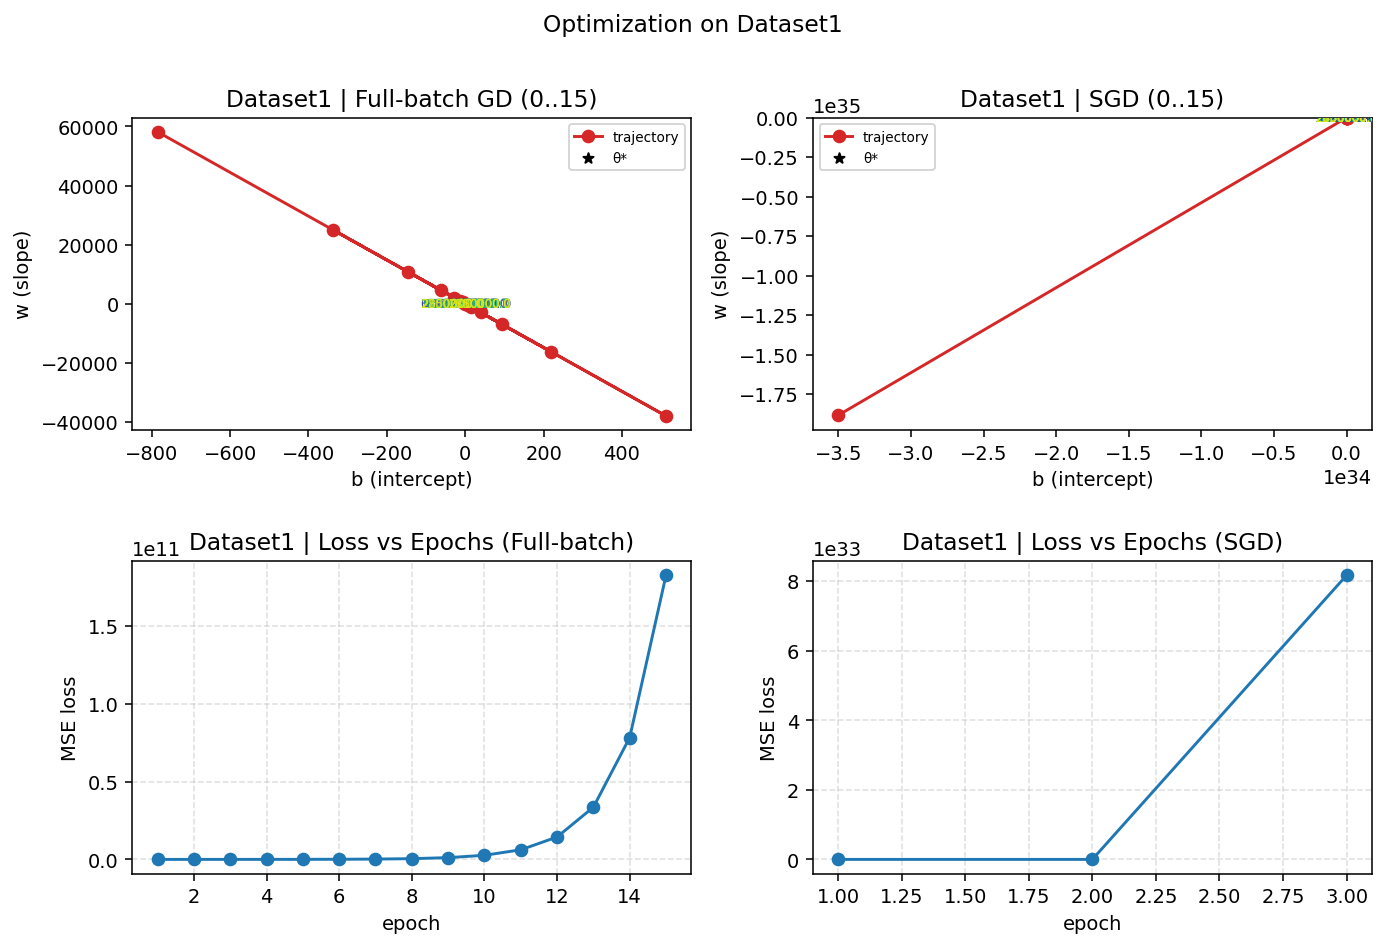

GIF generation skipped (install 'imageio' if needed). 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

Dataset1 θ*: [ 0.9506666 99.984116 ]
GD steps (first 5): [50000 50000 50000 50000 50000]
SGD steps (first 5): [50000 50000 50000 50000 50000]


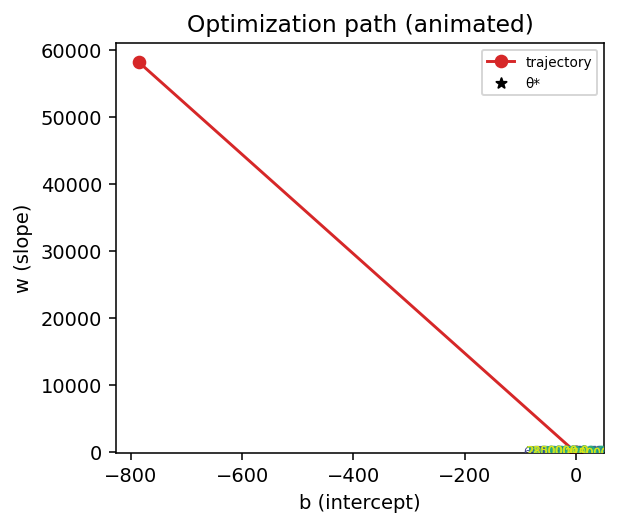

In [ ]:

X1, y1 = make_dataset_1()
stats1 = run_experiment(X1, y1, dataset_name="Dataset1")


print("\nDataset1 θ*:", stats1["theta_star"])
print("GD steps (first 5):", stats1["gd_steps"][:5])
print("SGD steps (first 5):", stats1["sgd_steps"][:5])


# **Full Batch Gradient Descent & Stochastic Gradient Descent of Dataset 1 with Safe Learning Rates**

L (Dataset1) = 2.527198e+02  ->  eta_safe ≈ 3.561e-03,  eta_sgd ≈ 7.123e-04
GD steps (safe LR):  1208
SGD steps (safe LR): 3233


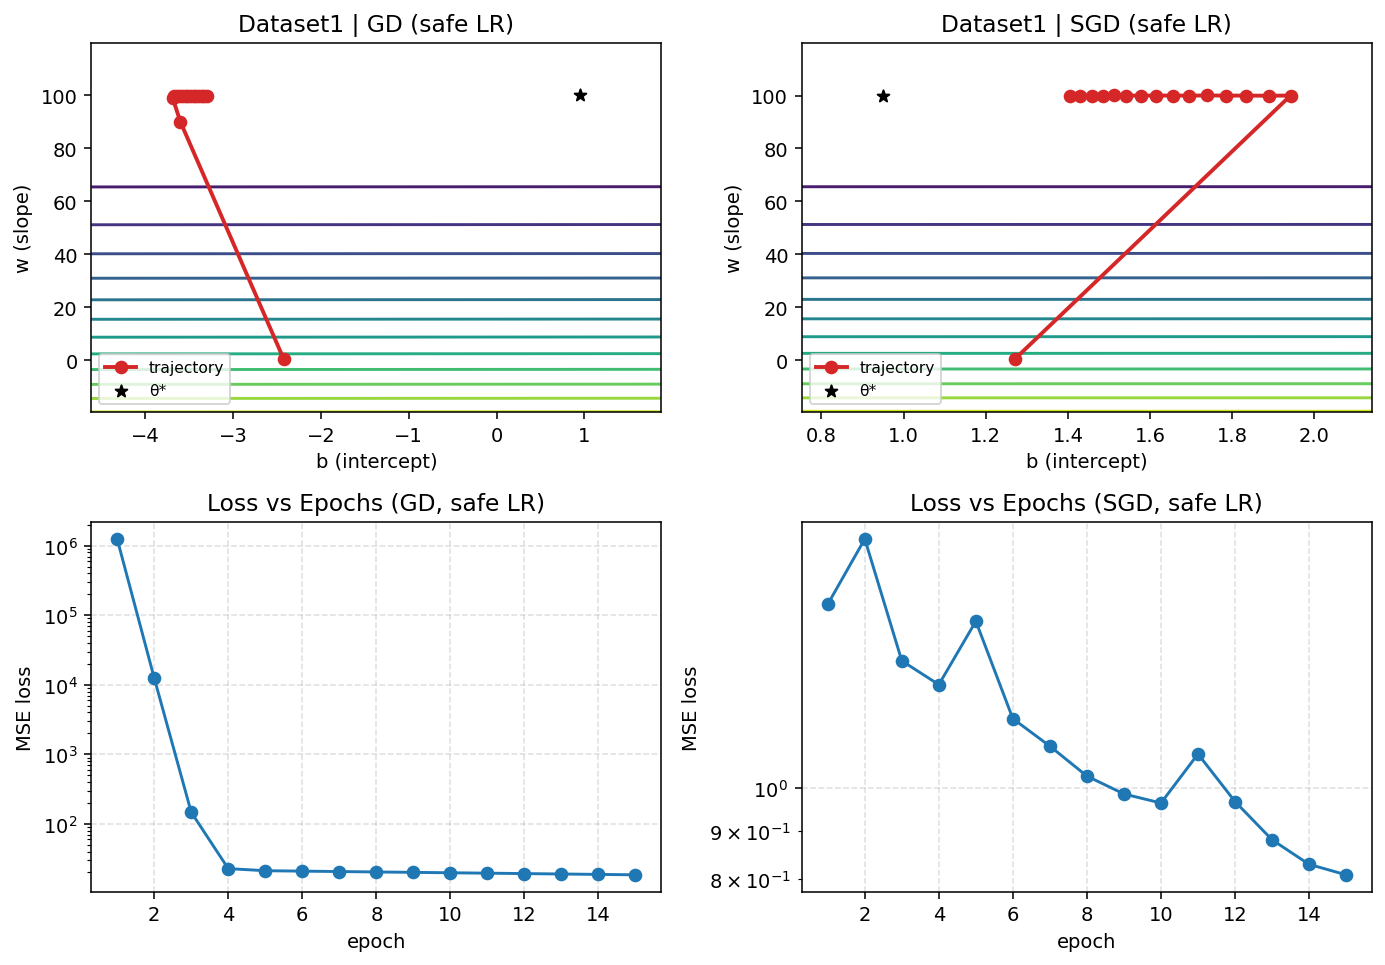

In [ ]:
import math


def lipschitz_L(X):
    XT_X = (X.t() @ X)

    evals = torch.linalg.eigvalsh(XT_X)
    lam_max = float(evals.max().item())
    n = X.shape[0]
    return (2.0 / n) * lam_max

theta_star_1 = true_minimizer(X1, y1)
L1 = lipschitz_L(X1)

eta_safe = 0.9 / L1
eta_sgd  = 0.2 * eta_safe

print(f"L (Dataset1) = {L1:.6e}  ->  eta_safe ≈ {eta_safe:.3e},  eta_sgd ≈ {eta_sgd:.3e}")


path_b, losses_b, steps_b, snaps_b = full_batch_gd(
    X1, y1, theta_star_1, lr=eta_safe, log_epochs=EPOCHS_FOR_PLOTS, eps=EPS
)
path_s, losses_s, steps_s, snaps_s = sgd(
    X1, y1, theta_star_1, lr=eta_sgd, log_epochs=EPOCHS_FOR_PLOTS, seed=2025, eps=EPS
)

print(f"GD steps (safe LR):  {steps_b}")
print(f"SGD steps (safe LR): {steps_s}")


def make_contour_clean(ax, X, y, theta_path_epochs, title=""):
    theta_star = true_minimizer(X, y)
    b_star, w_star = theta_star.tolist()


    bs = [t[0].item() for t in theta_path_epochs] + [b_star]
    ws = [t[1].item() for t in theta_path_epochs] + [w_star]
    b_min, b_max = min(bs), max(bs)
    w_min, w_max = min(ws), max(ws)

    pad_b = 0.2 * (b_max - b_min + 1e-9)
    pad_w = 0.2 * (w_max - w_min + 1e-9)
    b_vals = np.linspace(b_min - pad_b, b_max + pad_b, 160)
    w_vals = np.linspace(w_min - pad_w, w_max + pad_w, 160)
    B, W = np.meshgrid(b_vals, w_vals)
    loss_grid = np.zeros_like(B)

    with torch.no_grad():
        for i in range(B.shape[0]):
            BW_row = torch.tensor(np.stack([B[i], W[i]], axis=-1),
                                  dtype=torch.float32, device=DEVICE)
            yhat = X @ BW_row.T
            diffs = yhat - y.unsqueeze(1)
            loss_grid[i] = (diffs.pow(2).mean(dim=0)).cpu().numpy()


    CS = ax.contour(B, W, loss_grid, levels=12, cmap=cm.viridis)

    ax.plot(bs[:-1], ws[:-1], marker="o", lw=2.0, c="tab:red", label="trajectory")
    ax.scatter([b_star], [w_star], c="black", s=40, marker="*", label="θ*")

    ax.set_xlabel("b (intercept)")
    ax.set_ylabel("w (slope)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.ticklabel_format(style="plain")

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
make_contour_clean(axs[0,0], X1, y1, snaps_b, title="Dataset1 | GD (safe LR)")
make_contour_clean(axs[0,1], X1, y1, snaps_s, title="Dataset1 | SGD (safe LR)")

axs[1,0].plot(range(1, len(losses_b)+1), losses_b, marker="o")
axs[1,0].set_xlabel("epoch"); axs[1,0].set_ylabel("MSE loss")
axs[1,0].set_title("Loss vs Epochs (GD, safe LR)")
axs[1,0].grid(True, ls="--", alpha=0.4)
axs[1,0].set_yscale("log")

axs[1,1].plot(range(1, len(losses_s)+1), losses_s, marker="o")
axs[1,1].set_xlabel("epoch"); axs[1,1].set_ylabel("MSE loss")
axs[1,1].set_title("Loss vs Epochs (SGD, safe LR)")
axs[1,1].grid(True, ls="--", alpha=0.4)
axs[1,1].set_yscale("log")

fig.tight_layout()
plt.show()


# **Full Batch Gradient Descent and Stochastic Gradient Descent for Dataset 2**


=== Dataset2 ===
θ* (closed form): b*=3.950706, w*=2.682469
Average steps to ε=0.001 | Full-batch GD: 1286.5 ± 84.2 (min=1015, max=1384)
Average steps to ε=0.001 | SGD (bs=1):  15537.4 ± 15540.9 (min=1266, max=50000)


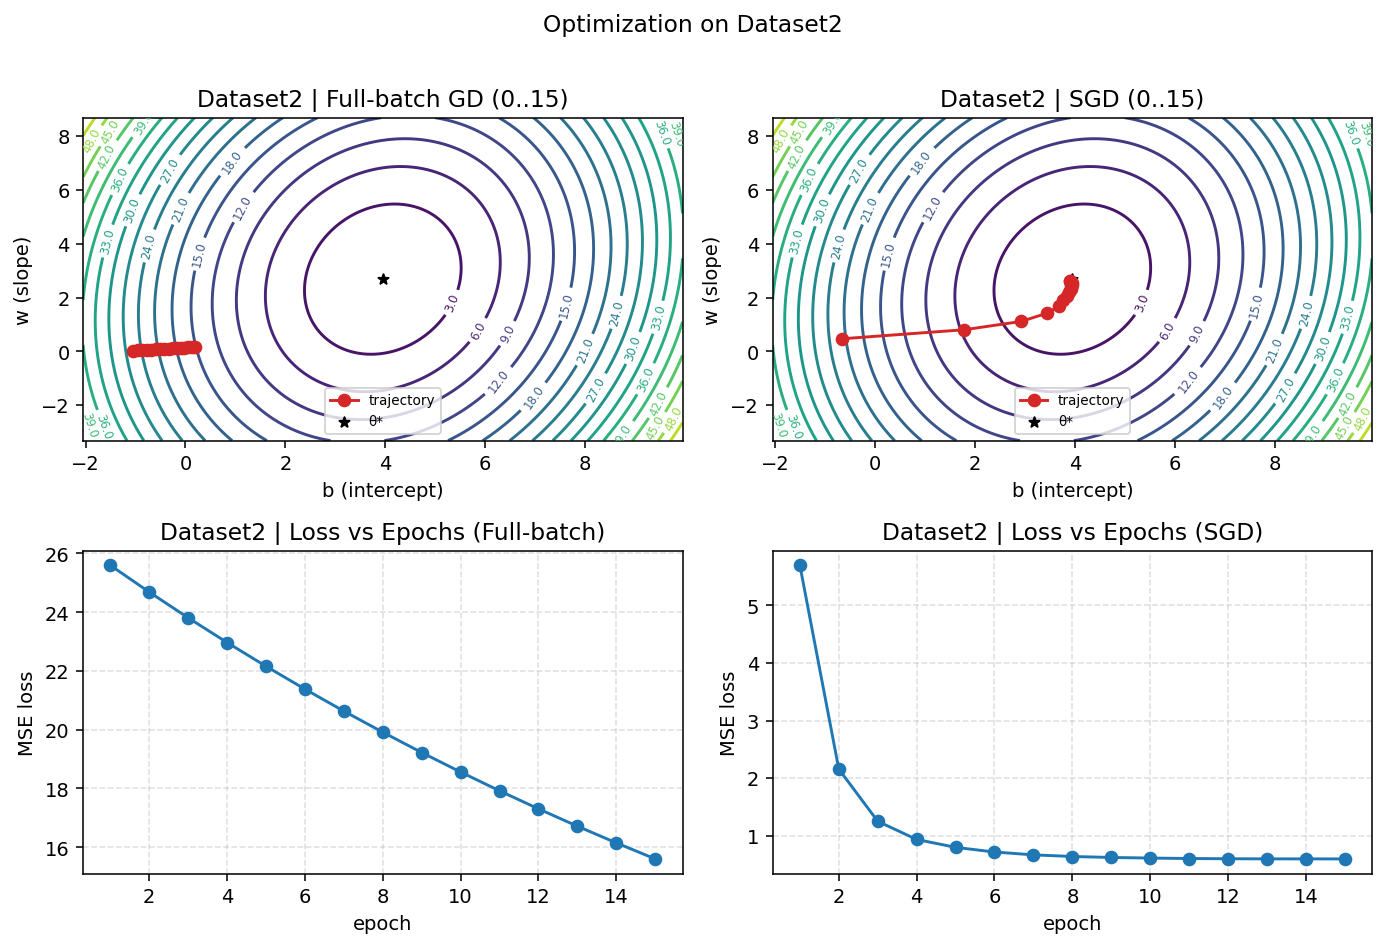

GIF generation skipped (install 'imageio' if needed). 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

Dataset2 θ*: [3.9507065 2.6824687]
GD steps (first 5): [1264 1336 1216 1345 1337]
SGD steps (first 5): [18763  2481 12419  7292 28368]


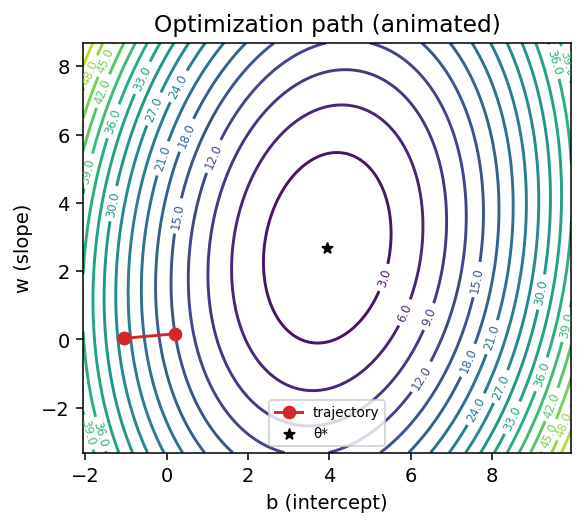

In [ ]:

X2, y2 = make_dataset_2()
stats2 = run_experiment(X2, y2, dataset_name="Dataset2")


print("\nDataset2 θ*:", stats2["theta_star"])
print("GD steps (first 5):", stats2["gd_steps"][:5])
print("SGD steps (first 5):", stats2["sgd_steps"][:5])
